# 15.1.2 反向传播与梯度核验

## 学习目标与先修知识

对同一计算图（computational graph）手推、反向累积并用中心差分（central difference）核验梯度（gradient）；识别不可微点。

先修：15.1.1 前向网络；链式法则（chain rule）、中心差分。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

训练代码给出一个梯度，怎样排除链式法则实现错误？差分步长越小是否必然越可靠？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
x,y,w,b,v,c=.7,.4,1.1,.2,.9,-.1;a=np.tanh(w*x+b);e=v*a+c-y;print("链式法则的 w 梯度：",e*v*(1-a*a)*x)

链式法则的 w 梯度： 0.048125623985668824


## 模型假设

代码中的 $x$ 是物理量 $x_{\mathrm{phys}}$（单位 U）除以 $1\,U$ 后的无量纲（dimensionless）数值，$w$、$b$ 亦无量纲。所有解析比较点都使用平滑的 tanh；用有限差分（finite difference）独立核对给定程序的局部导数（derivative）。ReLU 在 0 处没有通常的双侧导数，作为边界反例单独讨论。

## 数学解释与推导

设 $e=\hat y-y$、$a=\tanh(wx+b)$。按链式法则，$\partial_wL=ev(1-a^2)x$、$\partial_bL=ev(1-a^2)$、$\partial_vL=ea$、$\partial_cL=e$。反向模式从 $L$ 的导数 1 出发，按拓扑顺序反向累计。中心差分为 $[L(\theta+h)-L(\theta-h)]/(2h)$，其截断误差（truncation error）在光滑条件下随 $h$ 减小，但过小的 $h$ 会放大浮点抵消。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def scalar_net(x, w, b, v, c):
    return float(v * math.tanh(w * x + b) + c)


def scalar_loss_grad(x, y, w, b, v, c):
    z = w * x + b
    a = math.tanh(z)
    prediction = v * a + c
    error = prediction - y
    factor = error * v * (1 - a * a)
    return prediction, .5 * error * error, [factor * x, factor, error * a, error]


def finite_difference_grad(x, y, w, b, v, c, h):
    values = [w, b, v, c]
    gradients = []
    for j in range(4):
        plus, minus = values.copy(), values.copy()
        plus[j] += h
        minus[j] -= h
        lp = .5 * (scalar_net(x, *plus) - y)**2
        lm = .5 * (scalar_net(x, *minus) - y)**2
        gradients.append((lp - lm) / (2*h))
    return gradients


def reverse_tape_grad(x, y, w, b, v, c):
    """Tiny reverse-mode tape; a node can feed more than one downstream edge."""
    class Node:
        def __init__(self, value, parents=()):
            self.value = float(value)
            self.parents = parents
            self.grad = 0.

    def add(left, right):
        return Node(left.value+right.value, ((left,1.),(right,1.)))

    def mul(left, right):
        return Node(left.value*right.value,
                    ((left,right.value),(right,left.value)))

    def tanh(arg):
        value = math.tanh(arg.value)
        return Node(value, ((arg,1-value*value),))

    xnode, ynode = Node(x), Node(y)
    params = [Node(value) for value in (w,b,v,c)]
    z = add(mul(params[0],xnode),params[1])
    pred = add(mul(params[2],tanh(z)),params[3])
    error = add(pred,Node(-ynode.value))
    loss = mul(Node(.5),mul(error,error))
    visited, order = set(), []
    def visit(node):
        if id(node) in visited:
            return
        visited.add(id(node))
        for parent,_ in node.parents:
            visit(parent)
        order.append(node)
    visit(loss)
    loss.grad = 1.
    for node in reversed(order):
        for parent,local in node.parents:
            parent.grad += node.grad*local
    return pred.value, loss.value, [node.grad for node in params]

## 对照实验

先缩小中心差分步长，比较它与解析梯度的差；再用同一梯度更新小网络，分别观察训练点与验证点上的损失。

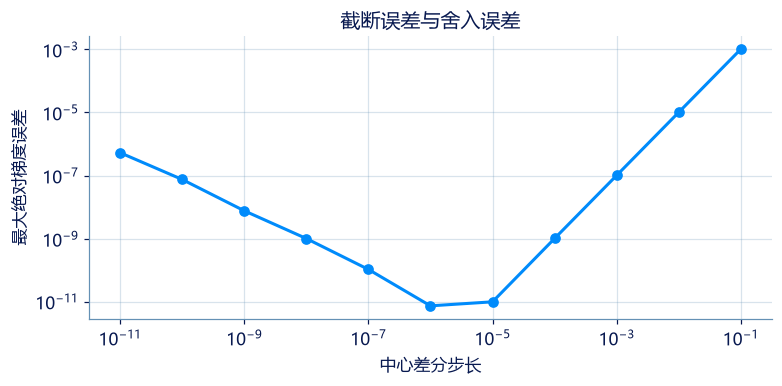

反向计算图： (0.5738338582723779, 0.015109105140930574, [0.048125623985668824, 0.06875089140809833, 0.13015015490894452, 0.17383385827237785])


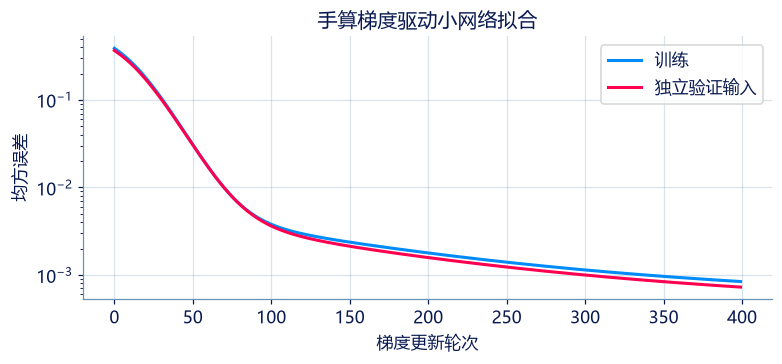

终点训练/验证误差： 0.0008397373849272817 0.0007253633205361249 ；未参与训练的 x=1.5 预测： 1.35731885971983


In [4]:
args=(.7,.4,1.1,.2,.9,-.1);exact=np.asarray(scalar_loss_grad(*args)[2]);steps=np.logspace(-1,-11,11);errors=[]
for h in steps:errors.append(np.max(np.abs(exact-np.asarray(finite_difference_grad(*args,h)))))
fig,ax=plt.subplots(figsize=(7,3.4));ax.loglog(steps,errors,"o-",color=BLUE);ax.set(xlabel="中心差分步长",ylabel="最大绝对梯度误差",title="截断误差与舍入误差");ax.grid(alpha=.25);plt.show()
print("反向计算图：",reverse_tape_grad(*args))

# Only the 15 training inputs enter the gradient updates. Validation and
# extrapolation points are evaluated after each epoch, never differentiated.
train_x=np.linspace(-1.,1.,15);train_y=1.2*np.tanh(1.5*train_x-.2)+.1
valid_x=np.linspace(-.93,.93,14);valid_y=1.2*np.tanh(1.5*valid_x-.2)+.1
params=np.array([.4,0.,.6,0.]);train_curve=[];valid_curve=[]
for epoch in range(400):
    derivatives=np.array([scalar_loss_grad(float(x),float(y),*params)[2]
                          for x,y in zip(train_x,train_y)])
    params-=.08*derivatives.mean(axis=0)
    train_curve.append(np.mean([(scalar_net(float(x),*params)-y)**2 for x,y in zip(train_x,train_y)]))
    valid_curve.append(np.mean([(scalar_net(float(x),*params)-y)**2 for x,y in zip(valid_x,valid_y)]))
fig,ax=plt.subplots(figsize=(7,3.2));ax.semilogy(train_curve,label="训练",color=BLUE)
ax.semilogy(valid_curve,label="独立验证输入",color=PINK)
ax.set(xlabel="梯度更新轮次",ylabel="均方误差",title="手算梯度驱动小网络拟合")
ax.legend();ax.grid(alpha=.25);plt.show()
print("终点训练/验证误差：",train_curve[-1],valid_curve[-1],
      "；未参与训练的 x=1.5 预测：",scalar_net(1.5,*params))


## 结果解释

在中等步长范围，差分与反传吻合；极小步长可能出现浮点误差。自动微分（automatic differentiation，AD）求的是实际计算图的导数，若程序实现了错误的方程，其梯度仍可能完全准确。 这里还用同一手算梯度训练了一神经元网络；验证输入（input）没有参加更新，训练集（training set）外的 x=1.5 仍须单独评估，不因训练曲线下降而获得保证。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
manual=scalar_loss_grad(*args);tape=reverse_tape_grad(*args)
np.testing.assert_allclose(tape[0:2],manual[0:2],atol=1e-14)
np.testing.assert_allclose(tape[2],manual[2],atol=1e-14)
assert abs(max(0.,1e-6)-max(0.,-1e-6))/(2e-6)==.5
print("手推、共享节点反传一致；ReLU 在零点的对称差分是约定值而非双侧导数。")
assert train_curve[-1]<train_curve[0] and valid_curve[-1]<valid_curve[0]
assert np.all(np.isfinite(params))
np.testing.assert_allclose(reverse_tape_grad(.7,.4,*params)[2],
                           scalar_loss_grad(.7,.4,*params)[2],atol=1e-12)
print("训练更新与最终参数的反传梯度核验通过。")


手推、共享节点反传一致；ReLU 在零点的对称差分是约定值而非双侧导数。
训练更新与最终参数的反传梯度核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：自动微分究竟对什么求导

反传结果与差分吻合时，能得出什么？

- **A.** 已证明生物模型（model）正确。
- **B.** 已证明训练集（training set）外预测良好。
- **C.** 当前光滑计算图（computational graph）的参数（parameter）导数（derivative）得到数值支持。
- **D.** 最小损失一定已找到。

[作答：自动微分究竟对什么求导](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-gradient-object)

### 第 2 题 · 单项选择题：非光滑点的差分

ReLU 在 0 点左右斜率（slope）分别为0与1。中心差分（central difference）给0.5，说明什么？

- **A.** ReLU 的双侧导数（derivative）为0.5。
- **B.** 中心差分一定是程序错误。
- **C.** 反向模式无法处理任何网络。
- **D.** 0.5 是对称差分值，不能当作通常双侧导数。

[作答：非光滑点的差分](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-nonsmooth)

### 第 3 题 · Python 计算题：反向计算图梯度

构造题给标量计算图（computational graph），并按 w,b,v,c 返回反向累积梯度（gradient）。

**函数与代码模板**

```python
def solve(
    x: float,
    y: float,
    w: float,
    b: float,
    v: float,
    c: float,
) -> tuple[float, float, list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 物理量 x_phys（单位 U）除以 1 U 后传给函数的无量纲（dimensionless）数值。 | 1 |
| `y` | `float` | 目标响应。 | U/T |
| `w` | `float` | 输入（input）权重。 | 1 |
| `b` | `float` | 偏置。 | 1 |
| `v` | `float` | 输出（output）权重。 | U/T |
| `c` | `float` | 输出偏置。 | U/T |

**返回值**

按以下顺序返回元组：(prediction, loss, gradient)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prediction` | `float` | 前向预测。 | U/T |
| `loss` | `float` | 半平方误差。 | (U/T)^2 |
| `gradient` | `list[float]` | 反向累积后的四个参数（parameter）梯度。 | 按参数 |

**计算规则**

计算图为 z=wx+b、a=tanh(z)、预测=va+c、损失=(预测-y)²/2；反向累计梯度。

**约束与边界**

- 输入规模不超过100，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 物理量 x_phys（单位 U）除以 1 U 后传给函数的无量纲（dimensionless）数值。 | 0.5 | 1 |
| y | 目标响应。 | 0 | U/T |
| w | 输入（input）权重。 | 1 | 1 |
| b | 偏置。 | 0 | 1 |
| v | 输出（output）权重。 | 1 | U/T |
| c | 输出偏置。 | 0 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 0.5
y = 0.0
w = 1.0
b = 0.0
v = 1.0
c = 0.0

result = solve(x, y, w, b, v, c)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| prediction | 前向预测。 | ≈ 0.4621172 | U/T |
| loss | 半平方误差。 | ≈ 0.1067761 | (U/T)^2 |
| gradient | 反向累积后的四个参数（parameter）梯度。 | [0.18171549534589682, 0.36343099069179363, 0.21355226703407257, 0.46211715726000974] | 按参数 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.46211715726000974,
                   0.10677613351703628,
                   [0.18171549534589682,
                    0.36343099069179363,
                    0.21355226703407257,
                    0.46211715726000974])
```

**样例解释**

损失的误差节点在平方计算中使用两次，反向贡献应相加。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：反向计算图梯度](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-reverse-graph)

### 第 4 题 · Python 计算题：中心差分核验

按给定中心差分（central difference）步长返回四个参数（parameter）的数值梯度（gradient）。

**函数与代码模板**

```python
def solve(
    x: float,
    y: float,
    w: float,
    b: float,
    v: float,
    c: float,
    h: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 物理量 x_phys（单位 U）除以 1 U 后传给函数的无量纲（dimensionless）数值。 | 1 |
| `y` | `float` | 目标。 | U/T |
| `w` | `float` | 输入（input）权重。 | 1 |
| `b` | `float` | 偏置。 | 1 |
| `v` | `float` | 输出（output）权重。 | U/T |
| `c` | `float` | 输出偏置。 | U/T |
| `h` | `float` | 参数数值的正扰动步长。 | 按参数 |

**返回值**

直接返回 gradient（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gradient` | `list[float]` | w,b,v,c 顺序的中心差分结果。 | 按参数 |

**计算规则**

每个参数单独计算 [L(参数+h)-L(参数-h)]/(2h)，损失=(v*tanh(wx+b)+c-y)²/2。

**约束与边界**

- h>0 且所有数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 物理量 x_phys（单位 U）除以 1 U 后传给函数的无量纲（dimensionless）数值。 | 0.5 | 1 |
| y | 目标。 | 0 | U/T |
| w | 输入（input）权重。 | 1 | 1 |
| b | 偏置。 | 0 | 1 |
| v | 输出（output）权重。 | 1 | U/T |
| c | 输出偏置。 | 0 | U/T |
| h | 参数数值的正扰动步长。 | 0.0001 | 按参数 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 0.5
y = 0.0
w = 1.0
b = 0.0
v = 1.0
c = 0.0
h = 0.0001

result = solve(x, y, w, b, v, c, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| gradient | w,b,v,c 顺序的中心差分结果。 | [0.18171549493427308, 0.36343098739823054, 0.21355226703406727, 0.46211715725996694] | 按参数 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.18171549493427308,
                   0.36343098739823054,
                   0.21355226703406727,
                   0.46211715725996694]
```

**样例解释**

对每个参数分别做正负扰动；不要把 h 同时加到所有参数上。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：中心差分核验](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-difference-check)